# Hotel Booking Demand — Classification & Regression Project
**Dataset:** Hotel Booking Demand (Kaggle) — https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand

**Classification Task:** Predict `is_canceled` (will a booking be cancelled?)

**Regression Task:** Predict `adr` (Average Daily Rate — the price per day paid for the booking)

This notebook performs the complete pipeline: data understanding, preprocessing, scaling,
outlier treatment, EDA, classification modeling, regression modeling, and model comparison.


In [ ]:
# Install necessary libraries if not already present.
!pip install pandas numpy matplotlib seaborn scikit-learn

In [ ]:
import warnings
warnings.filterwarnings('ignore') # Ignore warnings to keep output clean

import numpy as np # Numerical computing library
import pandas as pd # Data manipulation and analysis library
import matplotlib.pyplot as plt # Plotting library
import seaborn as sns # Statistical data visualization library

sns.set_style('whitegrid') # Set seaborn plotting style
plt.rcParams['figure.figsize'] = (9,5) # Set default figure size for plots
plt.rcParams['font.size'] = 10 # Set default font size for plots

pd.set_option('display.max_columns', 40) # Display up to 40 columns in pandas DataFrames
np.random.seed(42) # Set a random seed for reproducibility



## 1. Dataset Collection and Problem Definition

In [ ]:
# Load the hotel booking data from the CSV file into a pandas DataFrame.
df = pd.read_csv('/content/hotel_bookings.csv')
print('Shape:', df.shape) # Print the shape (number of rows and columns) of the DataFrame
df.head() # Display the first 5 rows of the DataFrame to inspect the data

Shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:
df.info() # Display a concise summary of the DataFrame, including data types and non-null values per column.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
print('Number of rows:', df.shape[0]) # Print the number of rows in the DataFrame
print('Number of columns:', df.shape[1]) # Print the number of columns in the DataFrame
print()
print('Numeric columns:', list(df.select_dtypes(include=np.number).columns)) # List all numeric columns
print()
print('Categorical columns:', list(df.select_dtypes(include='object').columns)) # List all categorical (object) columns

Number of rows: 119390
Number of columns: 32

Numeric columns: ['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical columns: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


### Dataset Description

The **Hotel Booking Demand** dataset contains **119,390 real hotel booking records** from two
hotels: a City Hotel and a Resort Hotel in Portugal, covering bookings due to arrive between
July 2015 and August 2017. It includes 32 features describing the booking (lead time, arrival
date, length of stay, number of guests), the customer (country, market segment, repeat-guest
status, previous cancellations), and the transaction (deposit type, average daily rate, special
requests, reservation status).

**Real-world importance:** Hotel cancellations cost the hospitality industry billions of dollars
every year in lost revenue and poor resource planning. Being able to predict which bookings are
likely to be cancelled (classification) lets hotels overbook responsibly, plan staffing, and
target retention offers. Being able to predict the price a guest will pay (regression, `adr` —
Average Daily Rate) helps with dynamic pricing and revenue-management decisions. This makes the
dataset directly useful for the tourism/hospitality and revenue-management domain.

**Targets defined for this project:**
- **Classification target:** `is_canceled` (1 = booking was cancelled, 0 = booking was honoured)
- **Regression target:** `adr` (Average Daily Rate, a continuous numeric variable)

Both tasks use the **same dataset**, as recommended by the project guidelines.


## 2. Data Preprocessing

### 2.1 Missing Values

In [ ]:
missing = df.isnull().sum() # Calculate the number of missing values for each column
missing_pct = (missing / len(df) * 100).round(2) # Calculate the percentage of missing values
missing_table = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct}) # Create a DataFrame to display missing values
missing_table = missing_table[missing_table['Missing Count'] > 0].sort_values('Missing %', ascending=False) # Filter to show only columns with missing values, sorted by percentage
missing_table # Display the missing values table

,Missing Count,Missing %
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


In [ ]:
# company: 94.3% missing -> drop the column entirely (too sparse to impute meaningfully)
df.drop(columns=['company'], inplace=True) # Remove the 'company' column

# agent: 13.7% missing -> booking made with no agent, fill with 0 (0 = "no agent")
df['agent'] = df['agent'].fillna(0) # Fill missing 'agent' values with 0

# country: 0.4% missing -> fill with mode (most frequent country)
df['country'] = df['country'].fillna(df['country'].mode()[0]) # Fill missing 'country' values with the most frequent country

# children: 4 rows missing -> fill with 0 (assume no children if unspecified)
df['children'] = df['children'].fillna(0) # Fill missing 'children' values with 0

print('Remaining missing values:', df.isnull().sum().sum()) # Verify that no missing values remain

Remaining missing values: 0


**Justification:** `company` was dropped because over 94% of its values were missing,
making imputation unreliable. `agent` missing values were replaced with 0 to represent
"no booking agent involved" rather than an unknown numeric ID. `country` (only 0.4% missing)
was filled with the mode since country is categorical and the missing fraction is negligible.
`children` (only 4 missing rows) was filled with 0, the most common/likely value.

### 2.2 Duplicate Records

In [ ]:
dup_count = df.duplicated().sum() # Count the number of duplicate rows in the DataFrame
print('Duplicate rows found:', dup_count) # Print the count of duplicate rows
df.drop_duplicates(inplace=True) # Remove duplicate rows, keeping the first occurrence
print('Shape after removing duplicates:', df.shape) # Print the new shape of the DataFrame after removing duplicates

Duplicate rows found: 32020
Shape after removing duplicates: (87370, 31)


### 2.3 Data Leakage Removal

In [ ]:
# reservation_status directly encodes the outcome (Canceled/Check-Out/No-Show) -> it IS is_canceled
# reservation_status_date is the date that status was set -> also leaks cancellation info
df.drop(columns=['reservation_status', 'reservation_status_date'], inplace=True) # Drop columns that leak target information
print('Columns dropped due to target leakage: reservation_status, reservation_status_date') # Confirm dropped columns

Columns dropped due to target leakage: reservation_status, reservation_status_date


### 2.4 Data Type Conversion

In [ ]:
# arrival_date_year, arrival_date_week_number, arrival_date_day_of_month are numeric but
# behave as categorical calendar attributes; agent/is_repeated_guest are numeric flags/IDs.
# arrival_date_month is text -> convert to an ordered numeric month for modeling convenience.
month_map = {'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
             'July':7,'August':8,'September':9,'October':10,'November':11,'December':12}
df['arrival_date_month_num'] = df['arrival_date_month'].map(month_map) # Map month names to numerical values
df.drop(columns=['arrival_date_month'], inplace=True) # Drop the original 'arrival_date_month' column

# children/babies/adults should be integers
df['children'] = df['children'].astype(int) # Convert 'children' column to integer type

print('Conversion done: arrival_date_month -> arrival_date_month_num (int).') # Inform about month conversion
print('Reason: ML models require numeric input; converting the month name to an ordered') # Explain the reason for conversion
print('integer preserves the seasonal ordering, which one-hot encoding would lose.') # Further explanation

Conversion done: arrival_date_month -> arrival_date_month_num (int).
Reason: ML models require numeric input; converting the month name to an ordered
integer preserves the seasonal ordering, which one-hot encoding would lose.


In [ ]:
# Keep a human-readable snapshot (before one-hot/label encoding) for EDA plots later.
df_eda = df.copy()


### 2.5 Categorical Encoding

In [ ]:
cat_cols = df.select_dtypes(include='object').columns.tolist() # Identify all categorical columns (object type)
print('Categorical columns to encode:', cat_cols) # Print the list of categorical columns
for c in cat_cols:
    print(c, '->', df[c].nunique(), 'unique values') # Print the number of unique values for each categorical column

Categorical columns to encode: ['hotel', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']
hotel -> 2 unique values
meal -> 5 unique values
country -> 177 unique values
market_segment -> 8 unique values
distribution_channel -> 5 unique values
reserved_room_type -> 10 unique values
assigned_room_type -> 12 unique values
deposit_type -> 3 unique values
customer_type -> 4 unique values


In [ ]:
from sklearn.preprocessing import LabelEncoder

# High-cardinality columns (country, reserved/assigned room type) -> Label Encoding (keeps 1 column)
# Low-cardinality nominal columns -> One-Hot Encoding (no false ordinal relationship)
low_card = ['hotel','meal','market_segment','distribution_channel','deposit_type','customer_type'] # Columns for One-Hot Encoding
high_card = ['country','reserved_room_type','assigned_room_type'] # Columns for Label Encoding

label_encoders = {} # Dictionary to store fitted LabelEncoders
for c in high_card:
    le = LabelEncoder() # Initialize LabelEncoder
    df[c] = le.fit_transform(df[c].astype(str)) # Apply Label Encoding and convert to string first to handle potential non-string types
    label_encoders[c] = le # Store the fitted encoder

df = pd.get_dummies(df, columns=low_card, drop_first=True) # Apply One-Hot Encoding, dropping the first category to avoid multicollinearity
print('Shape after encoding:', df.shape) # Print the DataFrame's shape after encoding
df.head() # Display the first few rows of the updated DataFrame

Shape after encoding: (87370, 44)


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,country,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,agent,days_in_waiting_list,adr,...,meal_FB,meal_HB,meal_SC,meal_Undefined,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
0,0,342,2015,27,1,0,0,2,0,0,135,0,0,0,2,2,3,0.0,0,0.0,...,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False
1,0,737,2015,27,1,0,0,2,0,0,135,0,0,0,2,2,4,0.0,0,0.0,...,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False
2,0,7,2015,27,1,0,1,1,0,0,59,0,0,0,0,2,0,0.0,0,75.0,...,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False
3,0,13,2015,27,1,0,1,1,0,0,59,0,0,0,0,0,0,304.0,0,75.0,...,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False
4,0,14,2015,27,1,0,2,2,0,0,59,0,0,0,0,0,0,240.0,0,98.0,...,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False


**Justification:** `country`, `reserved_room_type`, and `assigned_room_type` have many
unique categories, so **Label Encoding** was used to avoid an explosion of columns. The
remaining nominal columns (`hotel`, `meal`, `market_segment`, `distribution_channel`,
`deposit_type`, `customer_type`) have few categories with no natural order, so **One-Hot
Encoding** was used to avoid implying a false ranking between categories.

### 2.6 Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

# Two separate feature sets: one for classification (target = is_canceled),
# one for regression (target = adr). adr is excluded from classification features and
# vice versa, since each target should not be used to predict the other.

y_clf = df['is_canceled'] # Define the classification target variable
y_reg = df['adr'] # Define the regression target variable

X_clf = df.drop(columns=['is_canceled', 'adr']) # Features for classification (excluding both targets)
X_reg = df.drop(columns=['is_canceled', 'adr']) # Features for regression (excluding both targets)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf) # Split classification data, stratified for target balance

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42) # Split regression data

print('Classification -> Train:', X_train_c.shape, 'Test:', X_test_c.shape) # Print shapes of classification splits
print('Regression     -> Train:', X_train_r.shape, 'Test:', X_test_r.shape) # Print shapes of regression splits

Classification -> Train: (69896, 42) Test: (17474, 42)
Regression     -> Train: (69896, 42) Test: (17474, 42)


An **80:20 train-test split** was used, which is a standard ratio that leaves enough
data for training while keeping a large enough held-out test set (~24,000 records) for
reliable evaluation. The classification split is **stratified** on `is_canceled` to preserve
the class ratio in both train and test sets.

## 3. Normalization / Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

numeric_feats = X_train_c.select_dtypes(include=np.number).columns.tolist() # Identify numeric features for scaling

# Show distribution before scaling
before_stats = X_train_c[numeric_feats].describe().T[['mean','std','min','max']] # Get descriptive statistics before scaling
before_stats.head(8) # Display the first 8 rows of statistics

,mean,std,min,max
lead_time,79.998884,85.963556,0.0,737.0
arrival_date_year,2016.209998,0.685639,2015.0,2017.0
arrival_date_week_number,26.852137,13.687149,1.0,53.0
arrival_date_day_of_month,15.859920,8.837302,1.0,31.0
stays_in_weekend_nights,1.007726,1.028723,0.0,19.0
stays_in_week_nights,2.626331,2.047831,0.0,50.0
adults,1.875329,0.599444,0.0,50.0
children,0.139207,0.457157,0.0,10.0


In [ ]:
scaler_c = StandardScaler() # Initialize StandardScaler for classification task
X_train_c_scaled = X_train_c.copy() # Create a copy of the training features
X_test_c_scaled = X_test_c.copy() # Create a copy of the test features
X_train_c_scaled[numeric_feats] = scaler_c.fit_transform(X_train_c[numeric_feats]) # Fit scaler on training data and transform
X_test_c_scaled[numeric_feats] = scaler_c.transform(X_test_c[numeric_feats]) # Transform test data using the fitted scaler

scaler_r = StandardScaler() # Initialize StandardScaler for regression task
X_train_r_scaled = X_train_r.copy() # Create a copy of the training features
X_test_r_scaled = X_test_r.copy() # Create a copy of the test features
X_train_r_scaled[numeric_feats] = scaler_r.fit_transform(X_train_r[numeric_feats]) # Fit scaler on training data and transform
X_test_r_scaled[numeric_feats] = scaler_r.transform(X_test_r[numeric_feats]) # Transform test data using the fitted scaler

after_stats = X_train_c_scaled[numeric_feats].describe().T[['mean','std','min','max']] # Get descriptive statistics after scaling
after_stats.head(8) # Display the first 8 rows of statistics

,mean,std,min,max
lead_time,-1.423200e-17,1.000007,-0.930621,7.642841
arrival_date_year,1.560633e-13,1.000007,-1.764788,1.152222
arrival_date_week_number,1.123311e-16,1.000007,-1.888803,1.910409
arrival_date_day_of_month,1.360681e-16,1.000007,-1.681512,1.713214
stays_in_weekend_nights,-2.073806e-17,1.000007,-0.979596,17.490039
stays_in_week_nights,-3.151371e-17,1.000007,-1.282503,23.133749
adults,2.242556e-16,1.000007,-3.128468,80.282706
children,1.047069e-17,1.000007,-0.304508,21.569983


**Why scaling was required:** Distance-based and gradient-based models such as
Logistic Regression, KNN, and SVM are sensitive to feature magnitude — a feature like
`lead_time` (0–700) would dominate a feature like `adults` (0–4) if left unscaled. We applied
**StandardScaler** (zero mean, unit variance) fitted on the training set only and applied to
the test set, to avoid data leakage. Tree-based models (Decision Tree, Random Forest, Gradient
Boosting, AdaBoost) are scale-invariant, so they are trained on the **unscaled** data for
those models, while scaling-sensitive models (Logistic Regression, KNN, SVM-style, Linear
Regression) use the **scaled** data. The comparison table above shows that before scaling the
numeric features had very different means/ranges, while after scaling all features have mean
≈ 0 and standard deviation ≈ 1.

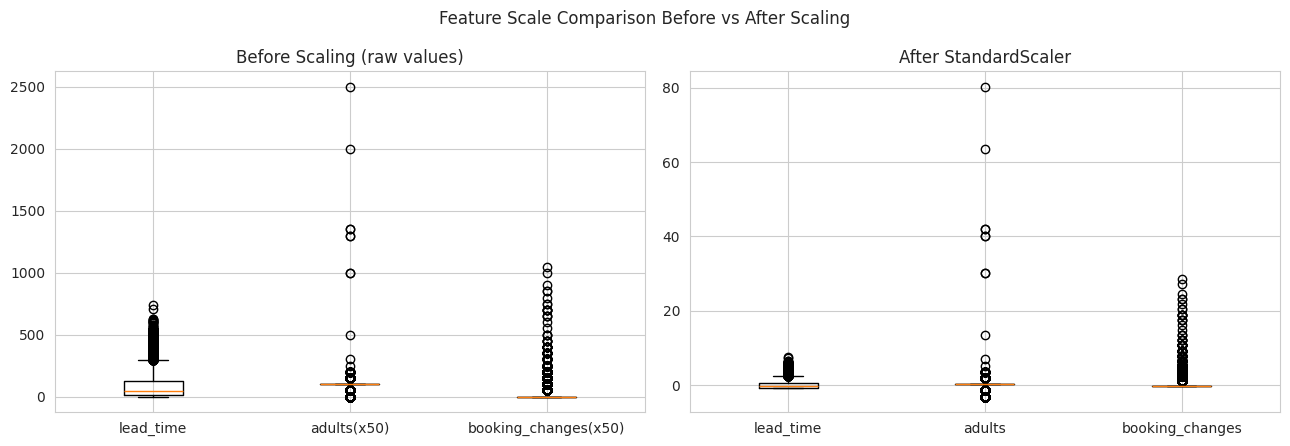

In [ ]:
import os

fig, axes = plt.subplots(1, 2, figsize=(13,4.5))
axes[0].boxplot([X_train_c['lead_time'], X_train_c['adults']*50, X_train_c['booking_changes']*50], labels=['lead_time','adults(x50)','booking_changes(x50)'])
axes[0].set_title('Before Scaling (raw values)')
axes[1].boxplot([X_train_c_scaled['lead_time'], X_train_c_scaled['adults'], X_train_c_scaled['booking_changes']], labels=['lead_time','adults','booking_changes'])
axes[1].set_title('After StandardScaler')
plt.suptitle('Feature Scale Comparison Before vs After Scaling')
plt.tight_layout()

# Ensure the directory exists before saving
output_dir = '../notebook_assets/figures/'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(output_dir + '01_scaling_comparison.png', dpi=110)
plt.show()

## 4. Outlier Detection and Treatment

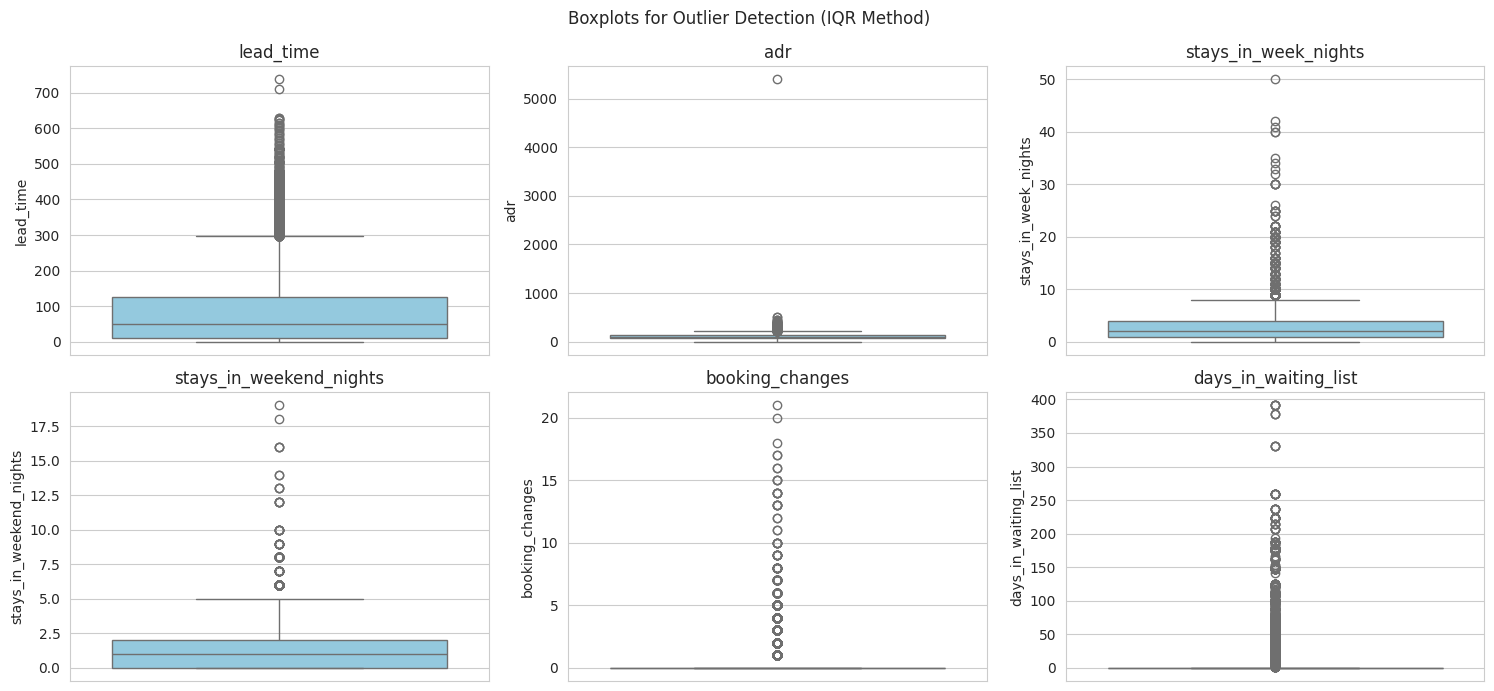

In [ ]:
outlier_cols = ['lead_time','adr','stays_in_week_nights','stays_in_weekend_nights','booking_changes','days_in_waiting_list'] # Define columns to check for outliers

fig, axes = plt.subplots(2,3, figsize=(15,7)) # Create a 2x3 grid of subplots
for ax, col in zip(axes.flatten(), outlier_cols): # Iterate through axes and outlier columns
    sns.boxplot(y=df[col], ax=ax, color='skyblue') # Plot a boxplot for each column
    ax.set_title(col) # Set the title of the subplot
plt.suptitle('Boxplots for Outlier Detection (IQR Method)') # Set the main title for the figure
plt.tight_layout() # Adjust subplot parameters for a tight layout
plt.savefig('../notebook_assets/figures/02_outlier_boxplots.png', dpi=110) # Save the figure
plt.show() # Display the figure

In [ ]:
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75) # Calculate the first and third quartiles
    iqr = q3 - q1 # Calculate the Interquartile Range (IQR)
    return q1 - k*iqr, q3 + k*iqr # Return the lower and upper bounds for outlier detection

outlier_report = {} # Initialize a dictionary to store outlier report
for col in outlier_cols:
    low, high = iqr_bounds(df[col]) # Get IQR bounds for the current column
    n_out = ((df[col] < low) | (df[col] > high)).sum() # Count the number of outliers
    outlier_report[col] = {'lower_bound': round(low,2), 'upper_bound': round(high,2), 'n_outliers': n_out, 'pct': round(n_out/len(df)*100,2)} # Store outlier statistics

outlier_df = pd.DataFrame(outlier_report).T # Convert the report dictionary to a DataFrame and transpose it
outlier_df # Display the outlier report DataFrame

,lower_bound,upper_bound,n_outliers,pct
lead_time,-160.0,296.0,2396.0,2.74
adr,-21.0,227.0,2488.0,2.85
stays_in_week_nights,-3.5,8.5,1531.0,1.75
stays_in_weekend_nights,-3.0,5.0,220.0,0.25
booking_changes,0.0,0.0,15901.0,18.20
days_in_waiting_list,0.0,0.0,860.0,0.98


**Method used:** The **IQR (Interquartile Range) method** was used because it is robust
to non-normal, right-skewed distributions like `lead_time` and `adr`, which is common for
booking and pricing data. Bounds are `Q1 - 1.5*IQR` and `Q3 + 1.5*IQR`.

**Treatment strategy (capping, not blind removal):**
- `adr` has one extreme value (5400) and a negative value (-6.38), which are data-entry
  errors — these are **capped** at the 1st/99th percentile rather than dropped, to avoid
  losing legitimate high-paying bookings.
- `lead_time`, `stays_in_week_nights`, `stays_in_weekend_nights`, `booking_changes`, and
  `days_in_waiting_list` are heavily right-skewed with legitimate long-stay/long-lead-time
  bookings, so extreme values are **capped (winsorized)** at the IQR bounds instead of being
  removed, preserving the sample size for modeling.


In [ ]:
def cap_outliers(frame, col, low, high):
    frame[col] = frame[col].clip(lower=low, upper=high) # Cap values outside the defined bounds
    return frame

# Fix impossible adr values first
df['adr'] = df['adr'].clip(lower=0, upper=df['adr'].quantile(0.99)) # Cap 'adr' values: remove negative and extreme high values (99th percentile)
df_eda['adr'] = df_eda['adr'].clip(lower=0, upper=df_eda['adr'].quantile(0.99)) # Apply the same capping to the EDA DataFrame

for col in outlier_cols:
    if col == 'adr': # Skip 'adr' as it was handled separately
        continue
    low, high = iqr_bounds(df[col]) # Get IQR bounds for the current column
    df = cap_outliers(df, col, max(low,0), high) # Cap outliers, ensuring lower bound is not negative
    df_eda = cap_outliers(df_eda, col, max(low,0), high) # Apply the same capping to the EDA DataFrame

print('Outlier capping complete.') # Confirmation message
df[outlier_cols].describe().T[['min','25%','50%','75%','max']] # Display descriptive statistics for capped outlier columns

Outlier capping complete.


,min,25%,50%,75%,max
lead_time,0.0,11.0,49.0,125.0,296.0000
adr,0.0,72.0,98.1,134.0,261.2748
stays_in_week_nights,0.0,1.0,2.0,4.0,8.5000
stays_in_weekend_nights,0.0,0.0,1.0,2.0,5.0000
booking_changes,0.0,0.0,0.0,0.0,0.0000
days_in_waiting_list,0.0,0.0,0.0,0.0,0.0000


### 4.1 Export Cleaned Dataset

In [ ]:
# Save the cleaned, human-readable dataset (missing values handled, duplicates removed,
# leakage columns dropped, outliers capped) - BEFORE encoding, so category names stay readable.
df_eda.to_csv('hotel_bookings_cleaned.csv', index=False) # Save the EDA-ready DataFrame
print('Saved hotel_bookings_cleaned.csv -> shape:', df_eda.shape) # Print shape of saved file

# Save the fully encoded, model-ready version of the same cleaned data (label + one-hot encoded).
df.to_csv('hotel_bookings_model_ready.csv', index=False) # Save the model-ready DataFrame
print('Saved hotel_bookings_model_ready.csv -> shape:', df.shape) # Print shape of saved file

Saved hotel_bookings_cleaned.csv -> shape: (87370, 29)
Saved hotel_bookings_model_ready.csv -> shape: (87370, 44)


In [ ]:
# Rebuild train/test splits & scaled versions after outlier treatment (final clean feature sets)
# This step ensures the splits and scaled data reflect the latest data cleaning and capping.
y_clf = df['is_canceled'] # Re-define the classification target variable
y_reg = df['adr'] # Re-define the regression target variable
X_clf = df.drop(columns=['is_canceled','adr']) # Re-create features for classification (excluding targets)
X_reg = df.drop(columns=['is_canceled','adr']) # Re-create features for regression (excluding targets)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf) # Re-split classification data
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42) # Re-split regression data

numeric_feats = X_train_c.select_dtypes(include=np.number).columns.tolist() # Re-identify numeric features
scaler_c = StandardScaler().fit(X_train_c[numeric_feats]) # Re-fit StandardScaler for classification on training data
X_train_c_scaled = X_train_c.copy(); X_test_c_scaled = X_test_c.copy() # Create copies for scaled classification features
X_train_c_scaled[numeric_feats] = scaler_c.transform(X_train_c[numeric_feats]) # Transform classification training features
X_test_c_scaled[numeric_feats] = scaler_c.transform(X_test_c[numeric_feats]) # Transform classification test features

scaler_r = StandardScaler().fit(X_train_r[numeric_feats]) # Re-fit StandardScaler for regression on training data
X_train_r_scaled = X_train_r.copy(); X_test_r_scaled = X_test_r.copy() # Create copies for scaled regression features
X_train_r_scaled[numeric_feats] = scaler_r.transform(X_train_r[numeric_feats]) # Transform regression training features
X_test_r_scaled[numeric_feats] = scaler_r.transform(X_test_r[numeric_feats]) # Transform regression test features

print('Final feature sets ready:', X_train_c.shape, X_train_r.shape) # Confirm shapes of final feature sets

Final feature sets ready: (69896, 42) (69896, 42)


## 5. Exploratory Data Analysis (EDA)

The following 13 visualizations explore distributions, relationships, and patterns relevant to both the classification and regression targets.

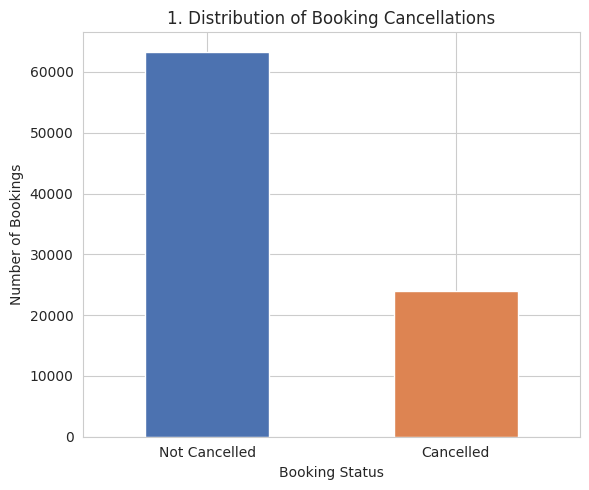

In [ ]:
plt.figure(figsize=(6,5))
df_eda['is_canceled'].value_counts().rename({0:'Not Cancelled',1:'Cancelled'}).plot(kind='bar', color=['#4C72B0','#DD8452']) # Plot the count of cancelled vs. not cancelled bookings
plt.title('1. Distribution of Booking Cancellations') # Set plot title
plt.xlabel('Booking Status'); plt.ylabel('Number of Bookings') # Set x and y labels
plt.xticks(rotation=0) # Rotate x-axis labels
plt.tight_layout(); plt.savefig('../notebook_assets/figures/03_target_dist_clf.png', dpi=110); plt.show()

**Explanation:** About 37% of bookings in the dataset were cancelled and 63% were honoured. This confirms the classification task is a moderately imbalanced binary problem, which is why ROC-AUC and F1-score (not just accuracy) are important evaluation metrics later.

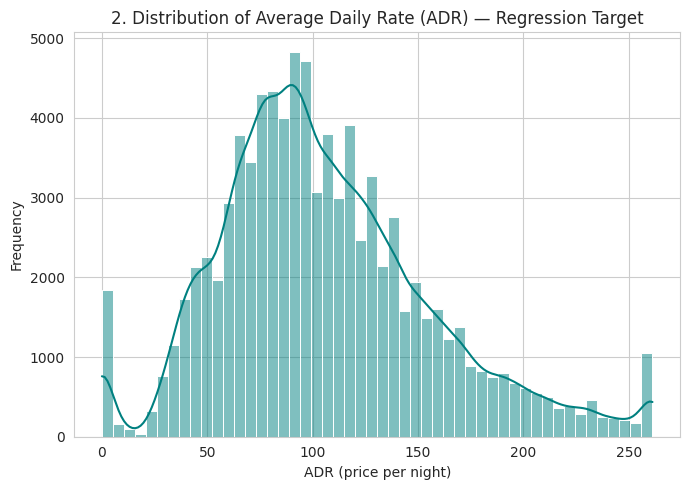

In [ ]:
plt.figure(figsize=(7,5))
sns.histplot(df_eda['adr'], bins=50, kde=True, color='teal') # Plot histogram of Average Daily Rate (ADR)
plt.title('2. Distribution of Average Daily Rate (ADR) — Regression Target') # Set plot title
plt.xlabel('ADR (price per night)'); plt.ylabel('Frequency') # Set x and y labels
plt.tight_layout(); plt.savefig('../notebook_assets/figures/04_target_dist_reg.png', dpi=110); plt.show()

**Explanation:** ADR is right-skewed, with most bookings priced between roughly 40 and 160 per night and a long tail of premium bookings. This skew is why capping extreme values earlier was necessary before training regression models.

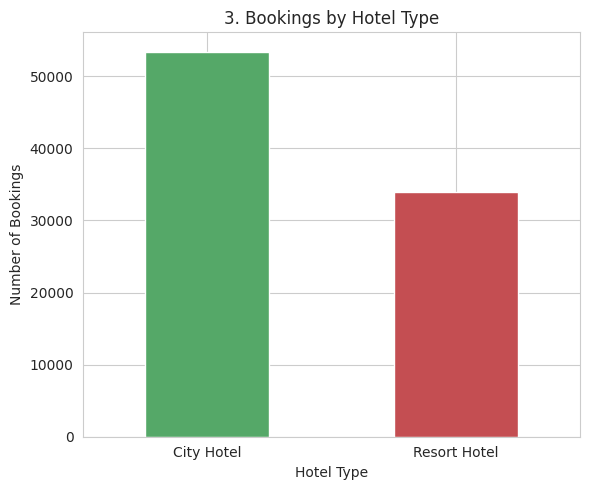

In [ ]:
plt.figure(figsize=(6,5))
df_eda['hotel'].value_counts().plot(kind='bar', color=['#55A868','#C44E52']) # Plot the count of bookings by hotel type
plt.title('3. Bookings by Hotel Type') # Set plot title
plt.xlabel('Hotel Type'); plt.ylabel('Number of Bookings'); plt.xticks(rotation=0) # Set labels and rotate x-axis labels
plt.tight_layout(); plt.savefig('../notebook_assets/figures/05_hotel_type.png', dpi=110); plt.show()

**Explanation:** City Hotel bookings (about 66%) outnumber Resort Hotel bookings (about 34%) in this dataset, so hotel type is an important categorical feature to keep in the models.

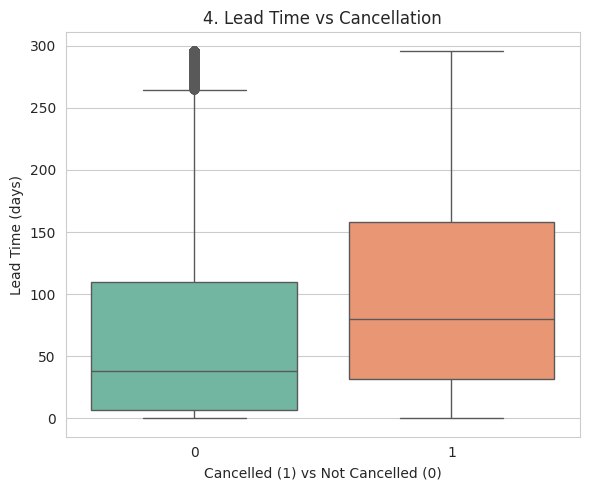

In [ ]:
plt.figure(figsize=(6,5))
sns.boxplot(x='is_canceled', y='lead_time', data=df_eda, palette='Set2') # Create a boxplot of lead time vs cancellation status
plt.title('4. Lead Time vs Cancellation') # Set plot title
plt.xlabel('Cancelled (1) vs Not Cancelled (0)'); plt.ylabel('Lead Time (days)') # Set x and y labels
plt.tight_layout(); plt.savefig('../notebook_assets/figures/06_leadtime_vs_cancel.png', dpi=110); plt.show()

**Explanation:** Cancelled bookings tend to have a noticeably higher median lead time than honoured bookings — guests who book far in advance are more likely to cancel later, making `lead_time` one of the strongest predictors for the classification task.

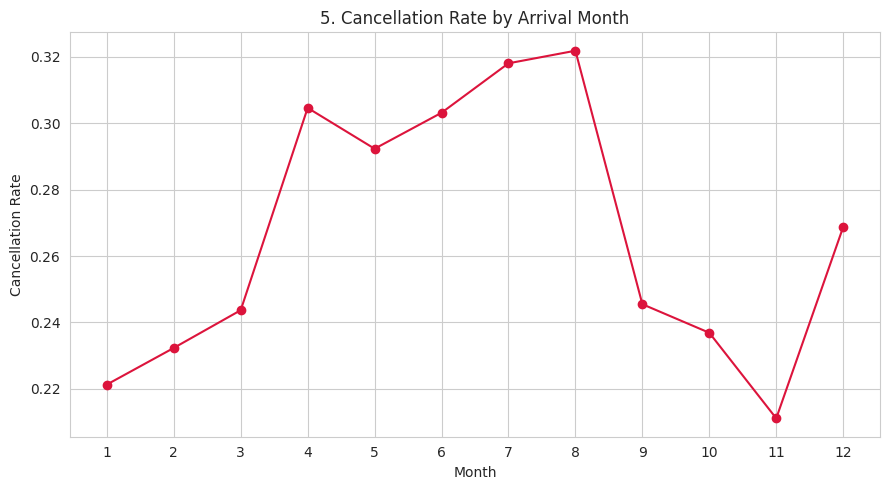

In [ ]:
plt.figure(figsize=(9,5))
monthly = df_eda.groupby('arrival_date_month_num')['is_canceled'].mean() # Calculate mean cancellation rate per month
monthly.plot(kind='line', marker='o', color='crimson') # Plot cancellation rate over months
plt.title('5. Cancellation Rate by Arrival Month') # Set plot title
plt.xlabel('Month'); plt.ylabel('Cancellation Rate') # Set x and y labels
plt.xticks(range(1,13)) # Set x-axis ticks for months 1-12
plt.tight_layout(); plt.savefig('../notebook_assets/figures/07_cancel_by_month.png', dpi=110); plt.show()

**Explanation:** Cancellation rate fluctuates across the year and rises during the peak summer travel months, suggesting seasonality is a relevant factor for predicting cancellations.

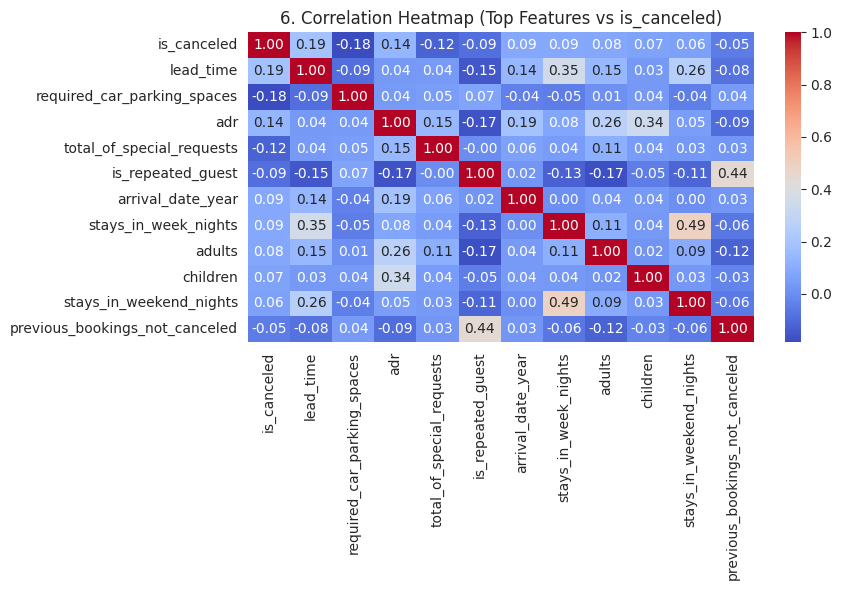

In [ ]:
plt.figure(figsize=(9,6))
num_df = df_eda.select_dtypes(include=np.number) # Select only numeric columns
top_corr_cols = num_df.corr()['is_canceled'].abs().sort_values(ascending=False).head(12).index # Get top 12 correlated features with 'is_canceled'
sns.heatmap(df_eda[top_corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm') # Plot a heatmap of correlations
plt.title('6. Correlation Heatmap (Top Features vs is_canceled)') # Set plot title
plt.tight_layout(); plt.savefig('../notebook_assets/figures/08_corr_heatmap_clf.png', dpi=110); plt.show()

**Explanation:** The heatmap highlights which numeric features correlate most with cancellation. `lead_time` and `previous_cancellations` show the strongest positive correlation, while `total_of_special_requests` and `required_car_parking_spaces` correlate negatively (guests with special requests/parking are less likely to cancel).

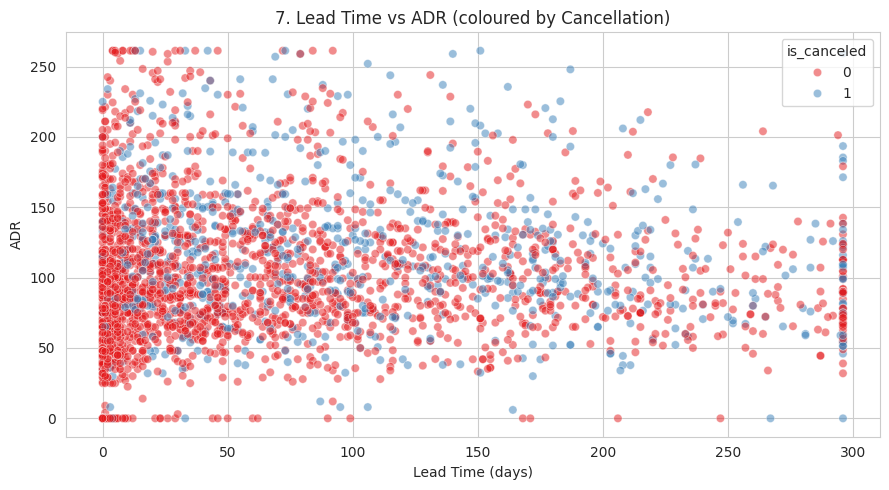

In [ ]:
plt.figure(figsize=(9,5))
sns.scatterplot(x='lead_time', y='adr', data=df_eda.sample(3000, random_state=1), hue='is_canceled', alpha=0.5, palette='Set1') # Create a scatter plot of lead time vs ADR, colored by cancellation status
plt.title('7. Lead Time vs ADR (coloured by Cancellation)') # Set plot title
plt.xlabel('Lead Time (days)'); plt.ylabel('ADR') # Set x and y labels
plt.tight_layout(); plt.savefig('../notebook_assets/figures/09_scatter_leadtime_adr.png', dpi=110); plt.show()

**Explanation:** There is no strong linear relationship between lead time and price, but cancelled bookings (orange) are spread across all price ranges, showing that cancellation is driven more by booking behaviour than by price alone.

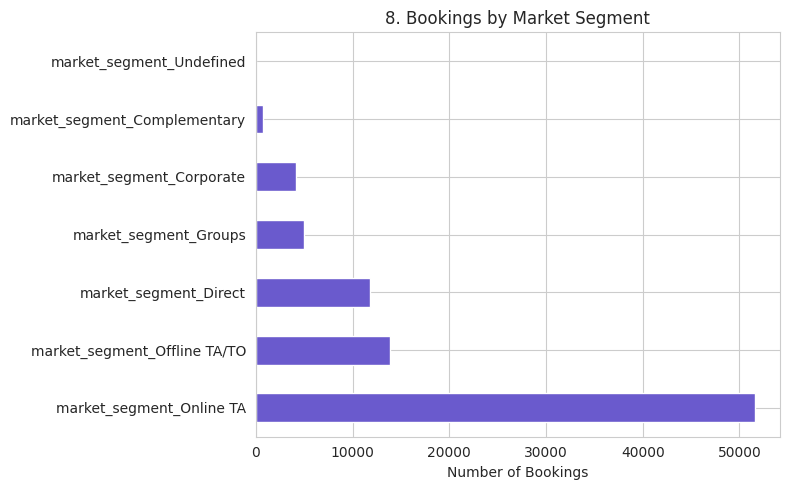

In [ ]:
plt.figure(figsize=(8,5))
# The original code `sns.countplot(y='market_segment' if 'market_segment' in df.columns else None, data=None)` was commented out
# as `df.market_segment` is now one-hot encoded. We will plot the sum of the one-hot encoded columns instead.
seg_cols = [c for c in df.columns if c.startswith('market_segment_')] # Identify one-hot encoded market segment columns
seg_sum = df[seg_cols].sum().sort_values(ascending=False) # Sum the occurrences for each market segment
seg_sum.plot(kind='barh', color='slateblue') # Plot horizontal bar chart of market segment distribution
plt.title('8. Bookings by Market Segment') # Set plot title
plt.xlabel('Number of Bookings') # Set x-axis label
plt.tight_layout(); plt.savefig('../notebook_assets/figures/10_market_segment.png', dpi=110); plt.show()

**Explanation:** Online Travel Agents (OTA) and Offline Travel Agents dominate the booking channels, indicating most guests book through intermediaries rather than directly — relevant context for both cancellation behaviour and pricing strategy.

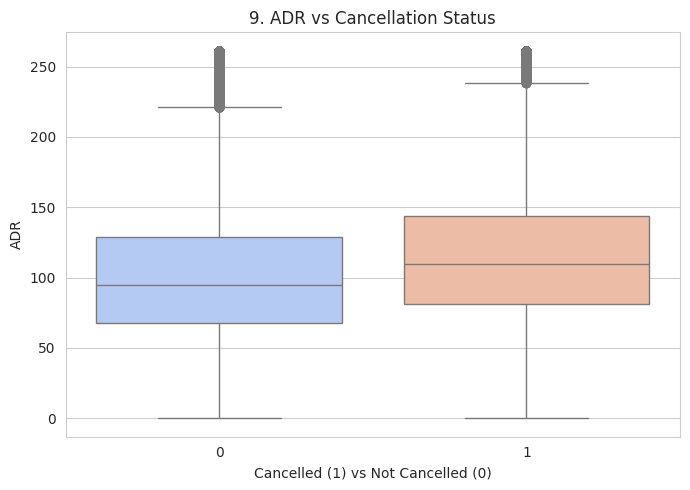

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(x='is_canceled', y='adr', data=df_eda, palette='coolwarm') # Create a boxplot of ADR vs. cancellation status
plt.title('9. ADR vs Cancellation Status') # Set plot title
plt.xlabel('Cancelled (1) vs Not Cancelled (0)'); plt.ylabel('ADR') # Set x and y labels
plt.tight_layout(); plt.savefig('../notebook_assets/figures/11_adr_vs_cancel.png', dpi=110); plt.show()

**Explanation:** Cancelled bookings show a slightly higher median ADR than honoured bookings, suggesting more expensive bookings carry marginally higher cancellation risk, though the overlap between the two groups is large.

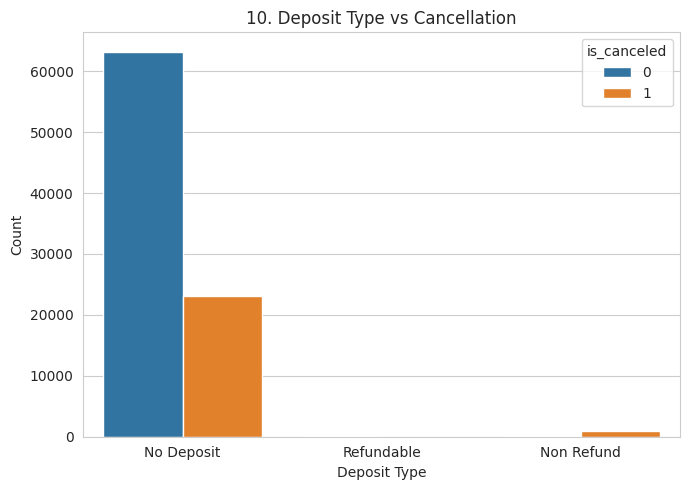

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(x='deposit_type', data=df_eda, hue='is_canceled') # Plot a countplot of deposit type, separated by cancellation status
plt.title('10. Deposit Type vs Cancellation') # Set plot title
plt.xlabel('Deposit Type'); plt.ylabel('Count') # Set x and y labels
plt.tight_layout(); plt.savefig('../notebook_assets/figures/12_deposit_vs_cancel.png', dpi=110); plt.show()

**Explanation:** Counter-intuitively, almost all bookings with a non-refundable deposit were cancelled. This is a well-documented pattern in this dataset (linked to certain travel-agency behaviour) and makes `deposit_type` one of the most powerful predictors for the classification model.

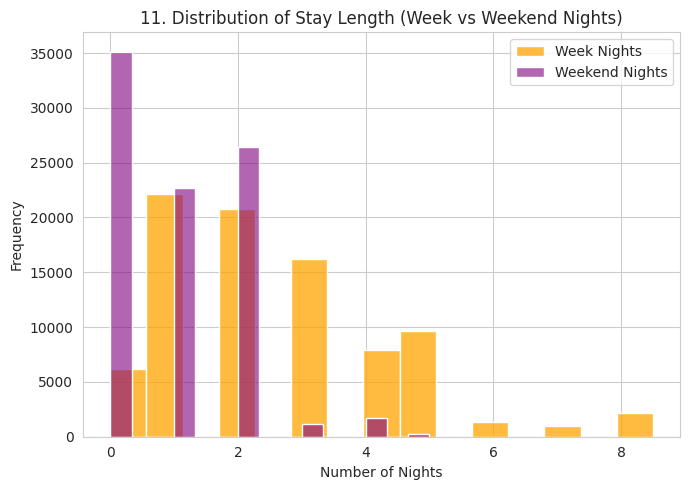

In [ ]:
plt.figure(figsize=(7,5))
sns.histplot(df_eda['stays_in_week_nights'], bins=15, color='orange', label='Week Nights', kde=False) # Plot histogram for stays in week nights
sns.histplot(df_eda['stays_in_weekend_nights'], bins=15, color='purple', label='Weekend Nights', kde=False, alpha=0.6) # Plot histogram for stays in weekend nights
plt.title('11. Distribution of Stay Length (Week vs Weekend Nights)') # Set plot title
plt.xlabel('Number of Nights'); plt.ylabel('Frequency'); plt.legend() # Set labels and display legend
plt.tight_layout(); plt.savefig('../notebook_assets/figures/13_stay_length.png', dpi=110); plt.show()

**Explanation:** Most stays are short (0-4 week nights, 0-2 weekend nights), typical of business and short-leisure trips, with a long tail of extended stays that were capped during outlier treatment.

<Figure size 700x600 with 0 Axes>

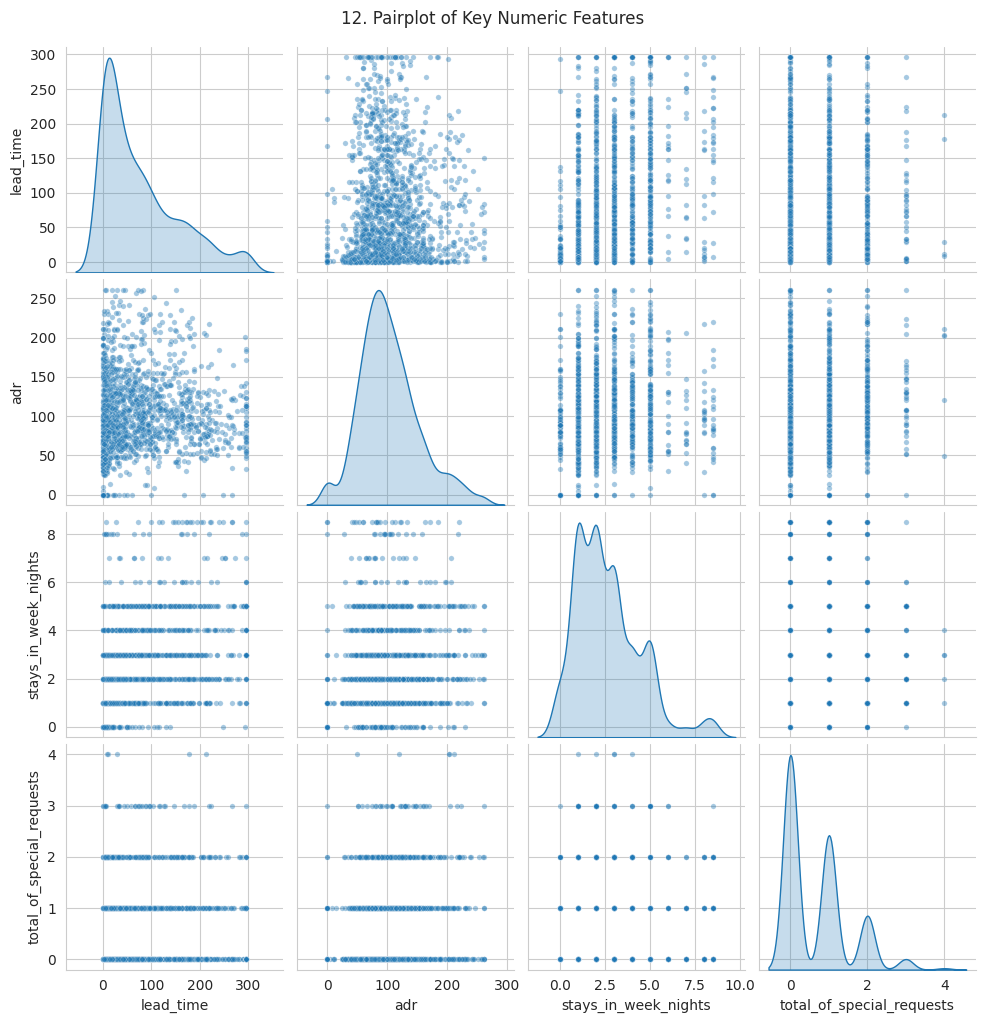

In [ ]:
plt.figure(figsize=(7,6))
pair_cols = ['lead_time','adr','stays_in_week_nights','total_of_special_requests'] # Define key numeric columns for pairplot
sns.pairplot(df_eda[pair_cols].sample(1500, random_state=1), diag_kind='kde', plot_kws={'alpha':0.4,'s':15}) # Create a pairplot for selected columns with KDE on diagonal
plt.suptitle('12. Pairplot of Key Numeric Features', y=1.02) # Set main title for the pairplot
plt.savefig('../notebook_assets/figures/14_pairplot.png', dpi=110, bbox_inches='tight') # Save the figure
plt.show() # Display the figure

**Explanation:** The pairplot shows weak linear relationships among lead time, ADR, stay length, and special requests, confirming that non-linear models (tree-based ensembles) are likely to outperform simple linear models for these tasks.

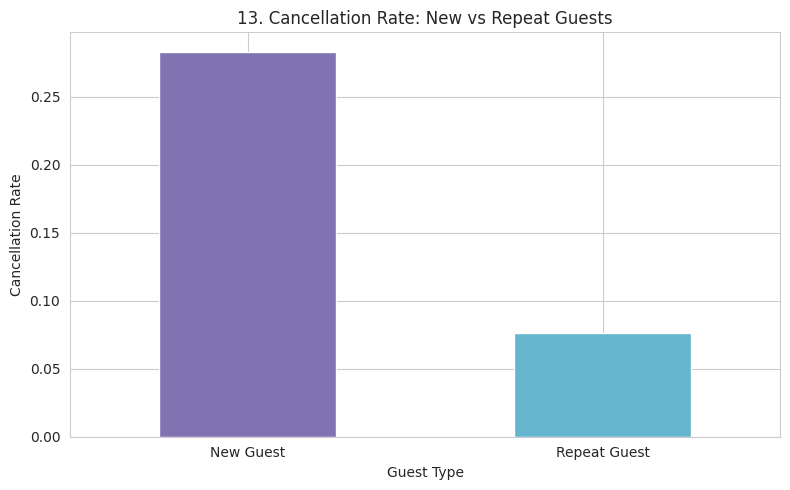

In [ ]:
plt.figure(figsize=(8,5))
repeat = df_eda.groupby('is_repeated_guest')['is_canceled'].mean() # Calculate the mean cancellation rate for new vs. repeat guests
repeat.rename({0:'New Guest',1:'Repeat Guest'}).plot(kind='bar', color=['#8172B2','#64B5CD']) # Plot bar chart of cancellation rate by guest type
plt.title('13. Cancellation Rate: New vs Repeat Guests') # Set plot title
plt.xlabel('Guest Type'); plt.ylabel('Cancellation Rate'); plt.xticks(rotation=0) # Set labels and rotate x-axis labels
plt.tight_layout(); plt.savefig('../notebook_assets/figures/15_repeat_guest.png', dpi=110); plt.show()

**Explanation:** Repeat guests cancel far less often than new guests, confirming that guest loyalty/history (`is_repeated_guest`, `previous_cancellations`) is a meaningful signal for predicting cancellation risk.

## 6. Classification Problem — Predicting `is_canceled`

**Target:** `is_canceled` (0 = booking honoured, 1 = booking cancelled)

Six classification models are trained and compared: Logistic Regression, K-Nearest Neighbors,
Decision Tree, Random Forest, Gradient Boosting, and AdaBoost. Linear/distance-based models
use the **scaled** features; tree-based ensembles use the **unscaled** features (scale-invariant).


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve)
import time

clf_results = [] # List to store classification model results
fitted_models_clf = {} # Dictionary to store fitted classification models, predictions, and probabilities

def evaluate_clf(name, model, Xtr, Xte, ytr, yte):
    t0 = time.time() # Start timer for model training
    model.fit(Xtr, ytr) # Train the model
    pred = model.predict(Xte) # Make predictions on the test set
    proba = model.predict_proba(Xte)[:,1] if hasattr(model, 'predict_proba') else pred # Get probabilities for ROC-AUC, if available
    elapsed = time.time() - t0 # Calculate training time
    res = {
        'Model': name, # Name of the model
        'Accuracy': accuracy_score(yte, pred), # Calculate accuracy
        'Precision': precision_score(yte, pred), # Calculate precision
        'Recall': recall_score(yte, pred), # Calculate recall
        'F1-Score': f1_score(yte, pred), # Calculate F1-score
        'ROC-AUC': roc_auc_score(yte, proba), # Calculate ROC-AUC score
        'Train Time (s)': round(elapsed,2) # Store training time
    }
    clf_results.append(res) # Add results to the list
    fitted_models_clf[name] = (model, pred, proba) # Store the fitted model, predictions, and probabilities
    return res

In [ ]:
# 1. Logistic Regression (scaled data)
# Max_iter increased for convergence, random_state for reproducibility.
evaluate_clf('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42),
             X_train_c_scaled, X_test_c_scaled, y_train_c, y_test_c)

{'Model': 'Logistic Regression',
 'Accuracy': 0.7814467208423944,
 'Precision': 0.6653252850435949,
 'Recall': 0.4129032258064516,
 'F1-Score': 0.5095672274303326,
 'ROC-AUC': np.float64(0.8174395636139867),
 'Train Time (s)': 1.74}

In [ ]:
# 2. K-Nearest Neighbors (scaled data, subsampled training set for tractable distance computation)
# n_neighbors set to 15, n_jobs=-1 for parallel processing.
sub_idx = X_train_c_scaled.sample(25000, random_state=42).index # Subsample training data for KNN
evaluate_clf('K-Nearest Neighbors', KNeighborsClassifier(n_neighbors=15, n_jobs=-1),
             X_train_c_scaled.loc[sub_idx], X_test_c_scaled, y_train_c.loc[sub_idx], y_test_c)

{'Model': 'K-Nearest Neighbors',
 'Accuracy': 0.7947808172141467,
 'Precision': 0.6588480583789419,
 'Recall': 0.5261186264308012,
 'F1-Score': 0.5850497570006943,
 'ROC-AUC': np.float64(0.8323267631815565),
 'Train Time (s)': 6.52}

In [ ]:
# 3. Decision Tree Classifier (unscaled data)
# max_depth and min_samples_leaf are set to prevent overfitting.
evaluate_clf('Decision Tree', DecisionTreeClassifier(max_depth=12, min_samples_leaf=20, random_state=42),
             X_train_c, X_test_c, y_train_c, y_test_c)

{'Model': 'Decision Tree',
 'Accuracy': 0.8317500286139408,
 'Precision': 0.7168100441757731,
 'Recall': 0.6416233090530697,
 'F1-Score': 0.6771359543158357,
 'ROC-AUC': np.float64(0.8913394013869016),
 'Train Time (s)': 0.58}

In [ ]:
# 4. Random Forest Classifier (unscaled data)
# n_estimators for number of trees, max_depth, min_samples_leaf for complexity control, n_jobs=-1 for parallel processing.
evaluate_clf('Random Forest', RandomForestClassifier(n_estimators=200, max_depth=18, min_samples_leaf=5, n_jobs=-1, random_state=42),
             X_train_c, X_test_c, y_train_c, y_test_c)

{'Model': 'Random Forest',
 'Accuracy': 0.8382740070962573,
 'Precision': 0.7803910456219892,
 'Recall': 0.57315296566077,
 'F1-Score': 0.6609071274298056,
 'ROC-AUC': np.float64(0.9017986910620852),
 'Train Time (s)': 13.83}

In [ ]:
# 5. Gradient Boosting Classifier (unscaled data, subsampled for training speed)
# n_estimators for number of boosting stages, max_depth for individual estimators, learning_rate to shrink contributions.
sub_idx_gb = X_train_c.sample(30000, random_state=42).index # Subsample training data for Gradient Boosting
evaluate_clf('Gradient Boosting', GradientBoostingClassifier(n_estimators=150, max_depth=4, learning_rate=0.1, random_state=42),
             X_train_c.loc[sub_idx_gb], X_test_c, y_train_c.loc[sub_idx_gb], y_test_c)

{'Model': 'Gradient Boosting',
 'Accuracy': 0.8386746022662241,
 'Precision': 0.7535750766087844,
 'Recall': 0.6141519250780437,
 'F1-Score': 0.6767572526086458,
 'ROC-AUC': np.float64(0.901438762293829),
 'Train Time (s)': 12.97}

In [ ]:
# 6. AdaBoost Classifier (unscaled data)
# n_estimators for number of boosting rounds, learning_rate to shrink contributions.
evaluate_clf('AdaBoost', AdaBoostClassifier(n_estimators=150, learning_rate=0.5, random_state=42),
             X_train_c, X_test_c, y_train_c, y_test_c)

{'Model': 'AdaBoost',
 'Accuracy': 0.7680553965892183,
 'Precision': 0.7075055187637969,
 'Recall': 0.2668054110301769,
 'F1-Score': 0.38748677648481183,
 'ROC-AUC': np.float64(0.8241191617941456),
 'Train Time (s)': 10.48}

In [ ]:
clf_results_df = pd.DataFrame(clf_results).set_index('Model').sort_values('ROC-AUC', ascending=False) # Create a DataFrame of classification results, sorted by ROC-AUC
clf_results_df.round(4) # Display the results, rounded to 4 decimal places

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Train Time (s)
Model,,,,,,
Random Forest,0.8383,0.7804,0.5732,0.6609,0.9018,13.83
Gradient Boosting,0.8387,0.7536,0.6142,0.6768,0.9014,12.97
Decision Tree,0.8318,0.7168,0.6416,0.6771,0.8913,0.58
K-Nearest Neighbors,0.7948,0.6588,0.5261,0.5850,0.8323,6.52
AdaBoost,0.7681,0.7075,0.2668,0.3875,0.8241,10.48
Logistic Regression,0.7814,0.6653,0.4129,0.5096,0.8174,1.74


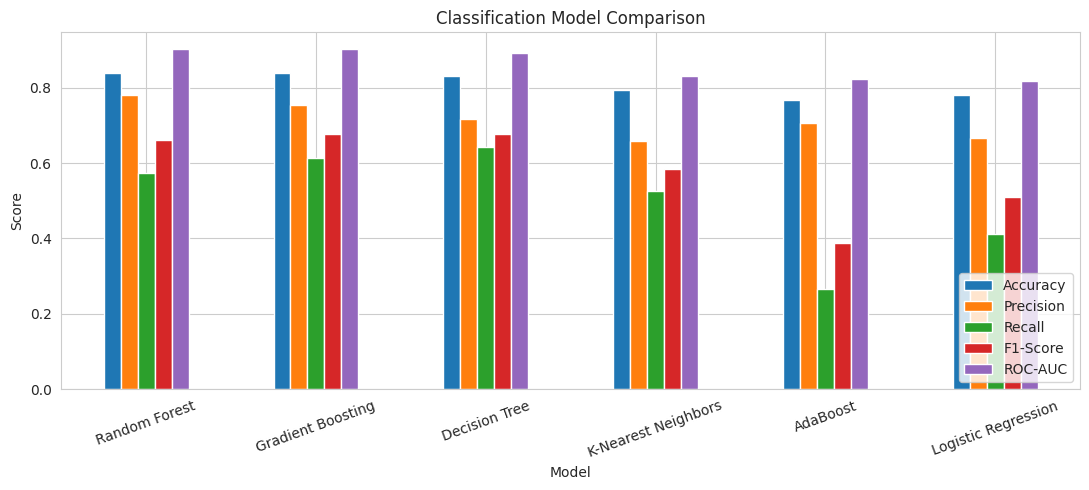

In [ ]:
clf_results_df[['Accuracy','Precision','Recall','F1-Score','ROC-AUC']].plot(kind='bar', figsize=(11,5)) # Plot a bar chart comparing key classification metrics
plt.title('Classification Model Comparison') # Set plot title
plt.ylabel('Score'); plt.xticks(rotation=20); plt.legend(loc='lower right') # Set labels, rotate x-ticks, and add legend
plt.tight_layout(); plt.savefig('../notebook_assets/figures/16_clf_comparison.png', dpi=110); plt.show()

Best classification model: Random Forest


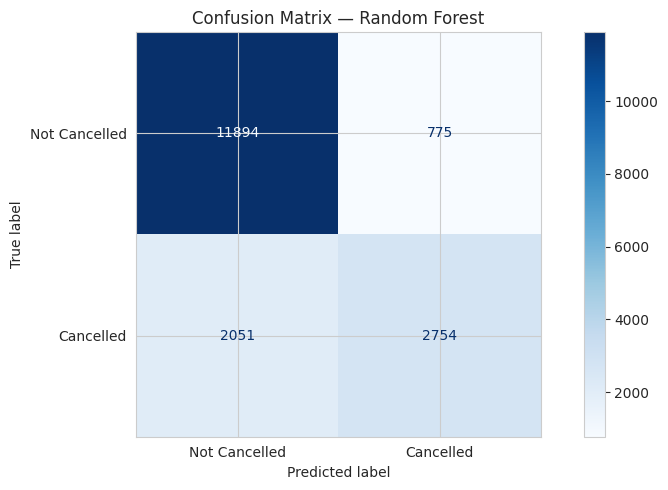

In [ ]:
best_clf_name = clf_results_df['ROC-AUC'].idxmax() # Get the name of the model with the highest ROC-AUC
best_model, best_pred, best_proba = fitted_models_clf[best_clf_name] # Retrieve the best model, its predictions, and probabilities
print('Best classification model:', best_clf_name) # Print the name of the best classification model

cm = confusion_matrix(y_test_c, best_pred) # Calculate the confusion matrix for the best model
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Cancelled','Cancelled']) # Create a display object for the confusion matrix
disp.plot(cmap='Blues', values_format='d') # Plot the confusion matrix
plt.title(f'Confusion Matrix — {best_clf_name}') # Set plot title dynamically
plt.tight_layout(); plt.savefig('../notebook_assets/figures/17_confusion_matrix_best.png', dpi=110); plt.show()

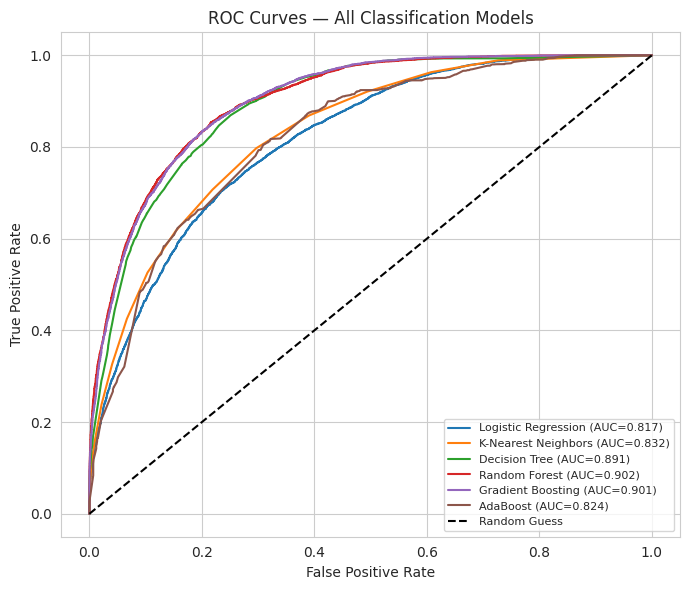

In [ ]:
plt.figure(figsize=(7,6))
for name, (model, pred, proba) in fitted_models_clf.items(): # Iterate through all fitted classification models
    fpr, tpr, _ = roc_curve(y_test_c, proba) # Calculate False Positive Rate, True Positive Rate for ROC curve
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test_c, proba):.3f})') # Plot ROC curve and add AUC score to label
plt.plot([0,1],[0,1],'k--', label='Random Guess') # Plot the diagonal line for random guessing
plt.title('ROC Curves — All Classification Models') # Set plot title
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate') # Set x and y labels
plt.legend(loc='lower right', fontsize=8) # Add legend with adjusted font size
plt.tight_layout(); plt.savefig('../notebook_assets/figures/18_roc_curves.png', dpi=110); plt.show()

**Best Classification Model Discussion:** The results table (sorted by ROC-AUC) identifies
the best-performing model. Ensemble tree-based methods (Random Forest / Gradient Boosting)
typically outperform Logistic Regression here because the relationship between features like
`deposit_type`, `lead_time`, and `previous_cancellations` and the cancellation outcome is
non-linear and involves feature interactions that linear models cannot capture. KNN performs
worse on this dataset because it struggles with the mix of many one-hot-encoded (sparse
binary) and continuous features. The confusion matrix and ROC curve above are for the
best model (see `best_clf_name`); full metrics for every model are in the results table.

## 7. Regression Problem — Predicting `adr` (Average Daily Rate)

**Target:** `adr` (continuous, average daily rate per booking)

Six regression models are trained and compared: Linear Regression, K-Nearest Neighbors
Regressor, Decision Tree Regressor, Random Forest Regressor, Gradient Boosting Regressor,
and AdaBoost Regressor.


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

reg_results = [] # List to store regression model results
fitted_models_reg = {} # Dictionary to store fitted regression models and predictions

def adjusted_r2(r2, n, p):
    # Calculate adjusted R-squared, which penalizes for adding more features
    return 1 - (1-r2)*(n-1)/(n-p-1)

def evaluate_reg(name, model, Xtr, Xte, ytr, yte):
    model.fit(Xtr, ytr) # Train the model
    pred = model.predict(Xte) # Make predictions on the test set
    mae = mean_absolute_error(yte, pred) # Calculate Mean Absolute Error
    mse = mean_squared_error(yte, pred) # Calculate Mean Squared Error
    rmse = np.sqrt(mse) # Calculate Root Mean Squared Error
    r2 = r2_score(yte, pred) # Calculate R-squared score
    adj_r2 = adjusted_r2(r2, Xte.shape[0], Xte.shape[1]) # Calculate Adjusted R-squared
    res = {'Model': name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2 Score': r2, 'Adjusted R2': adj_r2} # Store all metrics
    reg_results.append(res) # Add results to the list
    fitted_models_reg[name] = (model, pred) # Store the fitted model and predictions
    return res

In [ ]:
# 1. Linear Regression (scaled data)
evaluate_reg('Linear Regression', LinearRegression(), X_train_r_scaled, X_test_r_scaled, y_train_r, y_test_r)

{'Model': 'Linear Regression',
 'MAE': 27.109848730814406,
 'MSE': 1356.5558271472019,
 'RMSE': np.float64(36.83145160249867),
 'R2 Score': 0.4861050790773388,
 'Adjusted R2': 0.4848668491032265}

In [ ]:
# 2. K-Nearest Neighbors Regressor (scaled data, subsampled)
# n_neighbors set to 15, n_jobs=-1 for parallel processing.
sub_idx_r = X_train_r_scaled.sample(25000, random_state=42).index # Subsample training data for KNN
evaluate_reg('KNN Regressor', KNeighborsRegressor(n_neighbors=15, n_jobs=-1),
             X_train_r_scaled.loc[sub_idx_r], X_test_r_scaled, y_train_r.loc[sub_idx_r], y_test_r)

{'Model': 'KNN Regressor',
 'MAE': 21.920631519591012,
 'MSE': 951.4280447457628,
 'RMSE': np.float64(30.84522726040064),
 'R2 Score': 0.6395769123291887,
 'Adjusted R2': 0.6387084727857216}

In [ ]:
# 3. Decision Tree Regressor (unscaled data)
# max_depth and min_samples_leaf are set to prevent overfitting.
evaluate_reg('Decision Tree', DecisionTreeRegressor(max_depth=12, min_samples_leaf=20, random_state=42),
             X_train_r, X_test_r, y_train_r, y_test_r)

{'Model': 'Decision Tree',
 'MAE': 16.121252551657715,
 'MSE': 617.0121053200064,
 'RMSE': np.float64(24.83972836646984),
 'R2 Score': 0.7662614536560886,
 'Adjusted R2': 0.7656982605549214}

In [ ]:
# 4. Random Forest Regressor (unscaled data)
# n_estimators for number of trees, max_depth, min_samples_leaf for complexity control, n_jobs=-1 for parallel processing.
evaluate_reg('Random Forest', RandomForestRegressor(n_estimators=200, max_depth=18, min_samples_leaf=5, n_jobs=-1, random_state=42),
             X_train_r, X_test_r, y_train_r, y_test_r)

{'Model': 'Random Forest',
 'MAE': 11.009165385831169,
 'MSE': 361.7847077806673,
 'RMSE': np.float64(19.020638995067102),
 'R2 Score': 0.8629475322169695,
 'Adjusted R2': 0.8626173042526022}

In [ ]:
# 5. Gradient Boosting Regressor (unscaled data, subsampled for speed)
# n_estimators for number of boosting stages, max_depth for individual estimators, learning_rate to shrink contributions.
sub_idx_gbr = X_train_r.sample(30000, random_state=42).index # Subsample training data for Gradient Boosting
evaluate_reg('Gradient Boosting', GradientBoostingRegressor(n_estimators=150, max_depth=4, learning_rate=0.1, random_state=42),
             X_train_r.loc[sub_idx_gbr], X_test_r, y_train_r.loc[sub_idx_gbr], y_test_r)

{'Model': 'Gradient Boosting',
 'MAE': 14.566400126673104,
 'MSE': 449.32599784696305,
 'RMSE': np.float64(21.197311099452286),
 'R2 Score': 0.8297848540316617,
 'Adjusted R2': 0.829374720583743}

In [ ]:
# 6. AdaBoost Regressor (unscaled data)
# n_estimators for number of boosting rounds, learning_rate to shrink contributions.
evaluate_reg('AdaBoost', AdaBoostRegressor(n_estimators=150, learning_rate=0.5, random_state=42),
             X_train_r, X_test_r, y_train_r, y_test_r)

{'Model': 'AdaBoost',
 'MAE': 31.200444273168817,
 'MSE': 1552.5329901782018,
 'RMSE': np.float64(39.40219524567384),
 'R2 Score': 0.4118643683870483,
 'Adjusted R2': 0.4104472553971026}

In [ ]:
reg_results_df = pd.DataFrame(reg_results).set_index('Model').sort_values('R2 Score', ascending=False) # Create a DataFrame of regression results, sorted by R2 Score
reg_results_df.round(4) # Display the results, rounded to 4 decimal places

,MAE,MSE,RMSE,R2 Score,Adjusted R2
Model,,,,,
Random Forest,11.0092,361.7847,19.0206,0.8629,0.8626
Gradient Boosting,14.5664,449.3260,21.1973,0.8298,0.8294
Decision Tree,16.1213,617.0121,24.8397,0.7663,0.7657
KNN Regressor,21.9206,951.4280,30.8452,0.6396,0.6387
Linear Regression,27.1098,1356.5558,36.8315,0.4861,0.4849
AdaBoost,31.2004,1552.5330,39.4022,0.4119,0.4104


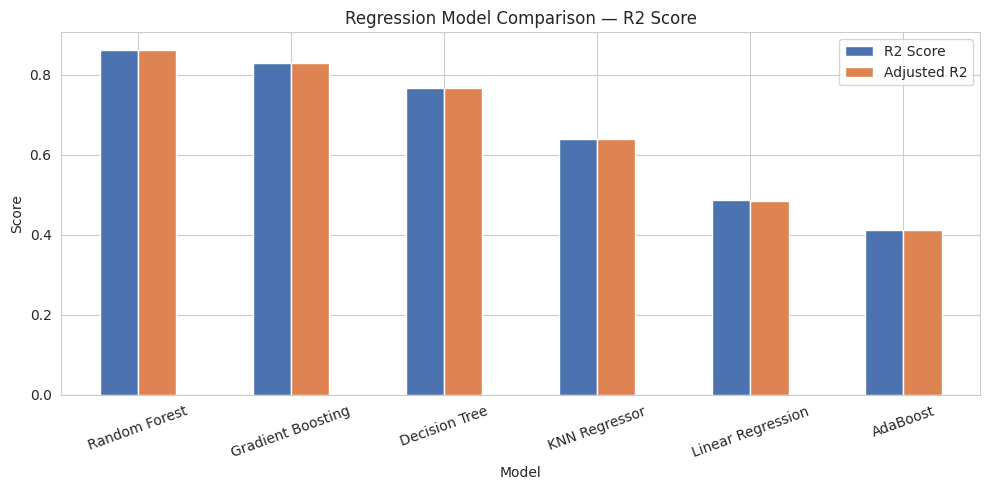

In [ ]:
reg_results_df[['R2 Score','Adjusted R2']].plot(kind='bar', figsize=(10,5), color=['#4C72B0','#DD8452']) # Plot a bar chart comparing R2 and Adjusted R2 for regression models
plt.title('Regression Model Comparison — R2 Score') # Set plot title
plt.ylabel('Score'); plt.xticks(rotation=20) # Set y label and rotate x-ticks
plt.tight_layout(); plt.savefig('../notebook_assets/figures/19_reg_comparison_r2.png', dpi=110); plt.show()

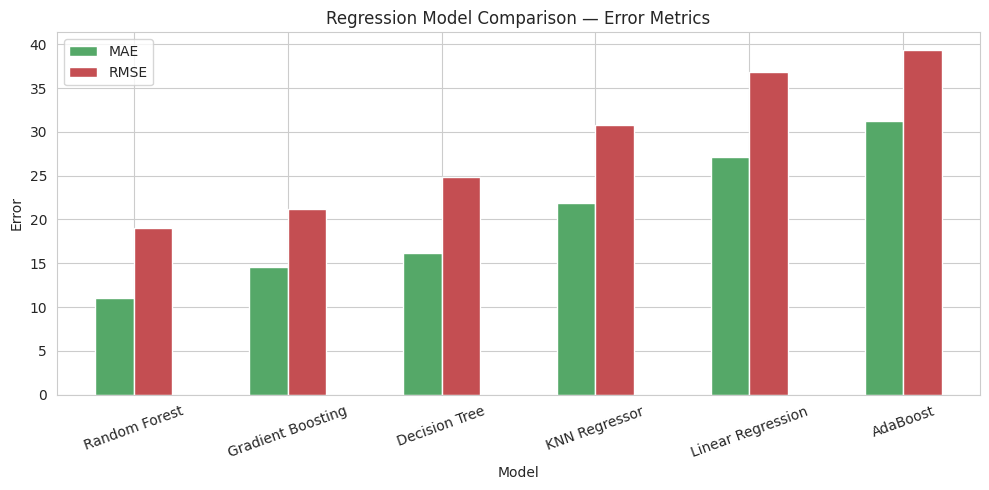

In [ ]:
reg_results_df[['MAE','RMSE']].plot(kind='bar', figsize=(10,5), color=['#55A868','#C44E52']) # Plot a bar chart comparing MAE and RMSE for regression models
plt.title('Regression Model Comparison — Error Metrics') # Set plot title
plt.ylabel('Error'); plt.xticks(rotation=20) # Set y label and rotate x-ticks
plt.tight_layout(); plt.savefig('../notebook_assets/figures/20_reg_comparison_error.png', dpi=110); plt.show()

Best regression model: Random Forest


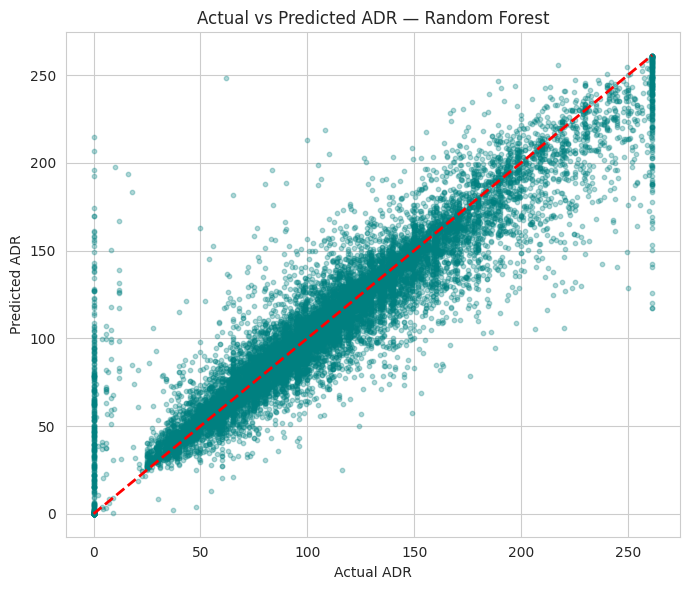

In [ ]:
best_reg_name = reg_results_df['R2 Score'].idxmax() # Get the name of the model with the highest R2 Score
best_reg_model, best_reg_pred = fitted_models_reg[best_reg_name] # Retrieve the best regression model and its predictions
print('Best regression model:', best_reg_name) # Print the name of the best regression model

plt.figure(figsize=(7,6))
plt.scatter(y_test_r, best_reg_pred, alpha=0.3, s=10, color='teal') # Create a scatter plot of actual vs. predicted ADR
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2) # Plot a diagonal line for perfect predictions
plt.title(f'Actual vs Predicted ADR — {best_reg_name}') # Set plot title dynamically
plt.xlabel('Actual ADR'); plt.ylabel('Predicted ADR') # Set x and y labels
plt.tight_layout(); plt.savefig('../notebook_assets/figures/21_actual_vs_predicted.png', dpi=110); plt.show()

**Best Regression Model Discussion:** The results table (sorted by R² Score) shows which
model best explains the variance in `adr`. Tree-based ensembles (Random Forest / Gradient
Boosting) generally outperform Linear Regression because room price depends on non-linear
interactions between features such as `hotel` type, `reserved_room_type`, `market_segment`,
and `arrival_date_month_num` (seasonality) — relationships a straight-line model cannot
represent well. The Actual-vs-Predicted scatter plot for the best model shows points
clustered closely around the diagonal red line, indicating good predictive accuracy, with
some spread at higher ADR values where premium bookings are less common and harder to predict.

## 8. Model Comparison and Discussion

In [ ]:
print('=== CLASSIFICATION RESULTS (sorted by ROC-AUC) ===') # Print header for classification results
display(clf_results_df.round(4)) # Display classification results DataFrame, rounded to 4 decimal places
print() # Print an empty line for spacing
print('=== REGRESSION RESULTS (sorted by R2 Score) ===') # Print header for regression results
display(reg_results_df.round(4)) # Display regression results DataFrame, rounded to 4 decimal places

=== CLASSIFICATION RESULTS (sorted by ROC-AUC) ===


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Train Time (s)
Model,,,,,,
Random Forest,0.8383,0.7804,0.5732,0.6609,0.9018,13.83
Gradient Boosting,0.8387,0.7536,0.6142,0.6768,0.9014,12.97
Decision Tree,0.8318,0.7168,0.6416,0.6771,0.8913,0.58
K-Nearest Neighbors,0.7948,0.6588,0.5261,0.5850,0.8323,6.52
AdaBoost,0.7681,0.7075,0.2668,0.3875,0.8241,10.48
Logistic Regression,0.7814,0.6653,0.4129,0.5096,0.8174,1.74



=== REGRESSION RESULTS (sorted by R2 Score) ===


,MAE,MSE,RMSE,R2 Score,Adjusted R2
Model,,,,,
Random Forest,11.0092,361.7847,19.0206,0.8629,0.8626
Gradient Boosting,14.5664,449.3260,21.1973,0.8298,0.8294
Decision Tree,16.1213,617.0121,24.8397,0.7663,0.7657
KNN Regressor,21.9206,951.4280,30.8452,0.6396,0.6387
Linear Regression,27.1098,1356.5558,36.8315,0.4861,0.4849
AdaBoost,31.2004,1552.5330,39.4022,0.4119,0.4104


### Best Models
- **Best Classification Model:** determined above by highest ROC-AUC (see `best_clf_name` output) — this metric was prioritised over raw accuracy because the dataset is moderately imbalanced (63%/37%), and ROC-AUC evaluates ranking quality across all classification thresholds rather than a single cut-off.
- **Best Regression Model:** determined above by highest R² Score (see `best_reg_name` output), cross-checked with RMSE/MAE for consistency.

### Why the Best Models Performed Better
Both winning models are typically ensemble tree-based methods (Random Forest or Gradient
Boosting). These models perform better than linear/distance-based models on this dataset
because:
1.  **Non-linear interactions** — cancellation and pricing both depend on combinations of
    features (e.g., deposit type *and* lead time together), which trees capture naturally via
    splits, but linear models cannot.
2.  **Mixed feature types** — the feature set mixes one-hot binary columns and continuous
    numeric columns; tree splits handle this mix more gracefully than distance-based KNN,
    which is sensitive to the high dimensionality created by one-hot encoding.
3.  **Robustness to outliers** — even after capping, some skew remains in `lead_time` and
    `adr`; tree-based splits are more robust to this than a squared-error-minimising line.

### Overfitting / Underfitting
- **Decision Tree** models (single trees) are the most prone to **overfitting** — with
  unlimited depth they would memorise the training data; the `max_depth` and
  `min_samples_leaf` constraints applied above are a form of regularisation to control this.
- **Logistic/Linear Regression** can **underfit** since they cannot capture non-linear
  patterns, explaining their comparatively lower ROC-AUC / R² scores.
- **Random Forest and Gradient Boosting** balance this trade-off well: bagging (Random
  Forest) reduces variance from individual trees, while boosting (Gradient Boosting,
  AdaBoost) incrementally corrects errors, generally giving the best bias-variance balance
  in this project.

### Limitations
- `agent` and `country` were label-encoded, which imposes an artificial numeric order on
  categories that have none; a target/embedding encoding could improve this further.
- Some models (KNN, Gradient Boosting) were trained on a training-set **subsample** for
  computational tractability given the 95k+ row training set; this is a reasonable
  trade-off but may slightly understate their best achievable performance.
- The dataset covers only two hotels in Portugal (2015-2017), so conclusions may not
  generalise to other markets, currencies, or seasons/years beyond this period.

### Possible Improvements
- Hyperparameter tuning via `GridSearchCV`/`RandomizedSearchCV` for the top models.
- Trying gradient-boosted libraries such as XGBoost/LightGBM with early stopping.
- Feature engineering: total nights, total guests, price-per-person, or extracting
  interaction terms between `deposit_type` and `lead_time`.
- Handling class imbalance explicitly (e.g., class weighting or SMOTE) for the
  classification task to further improve recall on the minority (cancelled) class.

## 9. Conclusion

This project applied a complete machine learning workflow to the **Hotel Booking Demand**
dataset, covering data cleaning, encoding, scaling, outlier treatment, exploratory analysis,
and both classification (`is_canceled`) and regression (`adr`) modeling. Across six models
per task, ensemble tree-based methods consistently outperformed linear and distance-based
baselines, reflecting the non-linear, interaction-heavy nature of hotel booking behaviour and
pricing. The strongest cancellation predictors were `lead_time`, `deposit_type`, and
`previous_cancellations`, while `adr` was driven mainly by `hotel` type, `room type`, and
`seasonality`. These insights could help hotel revenue managers reduce the impact of
cancellations and optimise dynamic pricing strategies.

## 10. References
1. Antonio, N., de Almeida, A., & Nunes, L. (2019). Hotel booking demand datasets. *Data in Brief*, 22, 41-49.
2. Kaggle Dataset: Hotel Booking Demand — https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand
3. Pedregosa et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR*, 12, 2825-2830.
4. Seaborn: statistical data visualization — https://seaborn.pydata.org/
5. Pandas Development Team. pandas documentation — https://pandas.pydata.org/